In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/andresca94/MasterCard-Stock-Price-Prediction-Using-LSTM-and-GRU/refs/heads/main/Mastercard_stock_history.csv", date_format="Date", index_col="Date")
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2006-05-25,3.748967,4.283869,3.739664,4.279217,395343000,0.0,0.0
2006-05-26,4.307126,4.348058,4.103398,4.179680,103044000,0.0,0.0
2006-05-30,4.183400,4.184330,3.986184,4.093164,49898000,0.0,0.0
2006-05-31,4.125723,4.219679,4.125723,4.180608,30002000,0.0,0.0
2006-06-01,4.179678,4.474572,4.176887,4.419686,62344000,0.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3872 entries, 2006-05-25 to 2021-10-11
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          3872 non-null   float64
 1   High          3872 non-null   float64
 2   Low           3872 non-null   float64
 3   Close         3872 non-null   float64
 4   Volume        3872 non-null   int64  
 5   Dividends     3872 non-null   float64
 6   Stock Splits  3872 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 242.0+ KB


In [45]:
start = 2014
end = 2018

In [46]:
data = df.loc[f"{start}":f"{end}", "Low"]
data

Date
2014-01-02     78.991603
2014-01-03     78.601478
2014-01-06     78.473938
2014-01-07     79.182616
2014-01-08     79.659987
                 ...    
2017-12-22    147.152427
2017-12-26    146.741266
2017-12-27    147.925812
2017-12-28    148.023678
2017-12-29    148.180405
Name: Low, Length: 1007, dtype: float64

In [47]:
len(data)

1007

In [48]:
data.index

Index(['2014-01-02', '2014-01-03', '2014-01-06', '2014-01-07', '2014-01-08',
       '2014-01-09', '2014-01-10', '2014-01-13', '2014-01-14', '2014-01-15',
       ...
       '2017-12-15', '2017-12-18', '2017-12-19', '2017-12-20', '2017-12-21',
       '2017-12-22', '2017-12-26', '2017-12-27', '2017-12-28', '2017-12-29'],
      dtype='object', name='Date', length=1007)

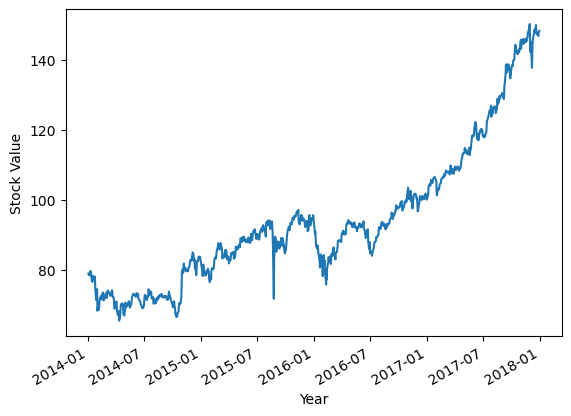

In [49]:
import matplotlib.pyplot as plt

plt.plot(pd.to_datetime(data.index), data.values)
plt.xlabel("Year")
plt.ylabel("Stock Value")
plt.gcf().autofmt_xdate()
plt.show()

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))
scaled_data[:3]

array([[-0.75854421],
       [-0.77780884],
       [-0.78410686]])

In [51]:
import numpy as np

x = []
y = []
window_size = 60
features = 1

for i in range(window_size, len(scaled_data)):
    x.append(scaled_data[i - window_size : i, 0])
    y.append(scaled_data[i, 0])


In [52]:
X, Y = np.array(x), np.array(y)

In [53]:
X

array([[-0.75854421, -0.77780884, -0.78410686, ..., -1.19234957,
        -1.25492964, -1.25069486],
       [-0.77780884, -0.78410686, -0.74911184, ..., -1.25492964,
        -1.25069486, -1.20081984],
       [-0.78410686, -0.74911184, -0.72553894, ..., -1.25069486,
        -1.20081984, -1.15941246],
       ...,
       [ 2.16934015,  2.18044115,  2.16209906, ...,  2.61308369,
         2.6072839 ,  2.58698052],
       [ 2.18044115,  2.16209906,  2.2263376 , ...,  2.6072839 ,
         2.58698052,  2.64547418],
       [ 2.16209906,  2.2263376 ,  2.24277592, ...,  2.58698052,
         2.64547418,  2.65030688]])

In [54]:
Y[:5]

array([-1.20081984, -1.15941246, -1.15235547, -1.16599986, -1.28504471])

In [55]:
X.shape

(947, 60)

In [56]:
X = np.reshape(X, (X.shape[0], X.shape[1], features))

In [57]:
X.shape

(947, 60, 1)

In [58]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [59]:
len(x_train), len(x_test)

(757, 190)

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

model = Sequential()
model.add(GRU(units=54, activation="tanh", return_sequences=True, input_shape=(window_size, features)))
model.add(Dropout(0.2))
model.add(GRU(units=54, activation="tanh"))
model.add(Dropout(0.2))
model.add(Dense(1))

In [62]:
model.compile(optimizer="Adam", loss="mean_squared_error")

In [63]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 60, 54)              │           9,234 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 54)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 54)                  │          17,820 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 54)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              55 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,109 (105.89 KB)

 Trainable params: 27,109 (105.89 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
history = model.fit(x_train, y_train, epochs=10)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 0.2887
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0265 
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0192 
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0178
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0191
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0171
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0159 
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0159
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0183
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0175 


In [65]:
preds = model.predict(x_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step


In [66]:
len(preds)

190

In [67]:
prediction = scaler.inverse_transform(preds)

In [69]:
actual_ytest = scaler.inverse_transform(y_test.reshape(-1, 1))

In [70]:
len(prediction), len(actual_ytest)

(190, 190)

In [74]:
epochs = list(range(1,11))
epochs

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [104]:
date = df.iloc[757:767].index
date

Index(['2009-05-29', '2009-06-01', '2009-06-02', '2009-06-03', '2009-06-04',
       '2009-06-05', '2009-06-08', '2009-06-09', '2009-06-10', '2009-06-11'],
      dtype='object', name='Date')

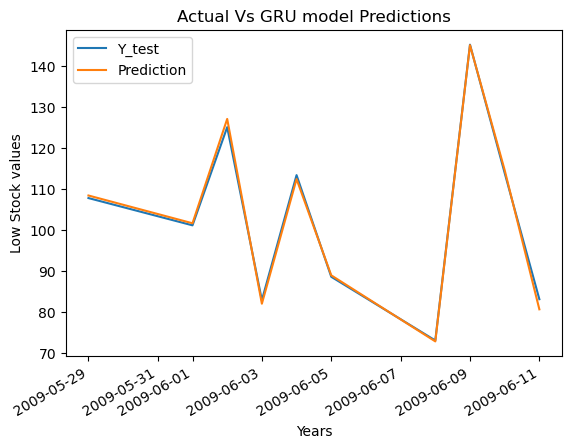

In [109]:
plt.plot(pd.to_datetime(date) ,actual_ytest[:10], label="Y_test")
plt.plot(pd.to_datetime(date) ,prediction[:10], label="Prediction")
plt.title("Actual Vs GRU model Predictions")
plt.xlabel("Years")
plt.ylabel("Low Stock values")
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()